# 04 — Modeling
**Purpose:** Train multiple regression models to predict plot/property price, compare their performance, and save the best model.

**Input:** `data/processed/train.csv`, `data/processed/test.csv`
**Output:** `models/best_model.pkl`, `models/model_comparison.csv`


In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

train = pd.read_csv("../data/processed/train.csv")
test = pd.read_csv("../data/processed/test.csv")

TARGET = "log_price"   # train on log-price for stability, convert back for interpretation
DROP = ["price", "log_price"]

X_train = train.drop(columns=DROP)
y_train = train[TARGET]
X_test = test.drop(columns=DROP)
y_test = test[TARGET]

# Keep raw price for reporting real-money errors
y_train_price = train["price"]
y_test_price = test["price"]

print(X_train.shape, X_test.shape)


(9887, 34) (2472, 34)


## 1. Define Models to Compare
Per the project brief, we compare several classic regression/classification-style algorithms
(adapted here to regression since price is continuous).


In [2]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1),
}


## 2. Train & Evaluate Each Model
Metrics computed on the **original price scale** (after inverse log-transform) so errors are interpretable in rupees.

In [3]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    pred_log = model.predict(X_test)
    pred_price = np.expm1(pred_log)
    pred_price = np.clip(pred_price, 0, None)

    mae = mean_absolute_error(y_test_price, pred_price)
    rmse = np.sqrt(mean_squared_error(y_test_price, pred_price))
    r2 = r2_score(y_test_price, pred_price)
    mape = np.mean(np.abs((y_test_price - pred_price) / y_test_price)) * 100

    results.append({
        "Model": name,
        "MAE (INR)": round(mae, 0),
        "RMSE (INR)": round(rmse, 0),
        "R2 Score": round(r2, 4),
        "MAPE (%)": round(mape, 2),
    })
    print(f"{name}: done")

results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False).reset_index(drop=True)
results_df


Linear Regression: done
Decision Tree: done
Random Forest: done
Gradient Boosting: done
XGBoost: done


,Model,MAE (INR),RMSE (INR),R2 Score,MAPE (%)
0,XGBoost,1414993.0,3032542.0,0.8579,25.30
1,Random Forest,1378931.0,3267047.0,0.8350,23.86
2,Gradient Boosting,1567751.0,3323042.0,0.8293,27.63
3,Decision Tree,1709196.0,3984280.0,0.7547,29.76
4,Linear Regression,3150461.0,14803737.0,-2.3870,50.03


## 3. Visual Comparison

C:\Users\DELL\AppData\Local\Temp\ipykernel_15992\2026835033.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2 Score", ax=axes[0], palette="viridis")
C:\Users\DELL\AppData\Local\Temp\ipykernel_15992\2026835033.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="MAPE (%)", ax=axes[1], palette="magma")


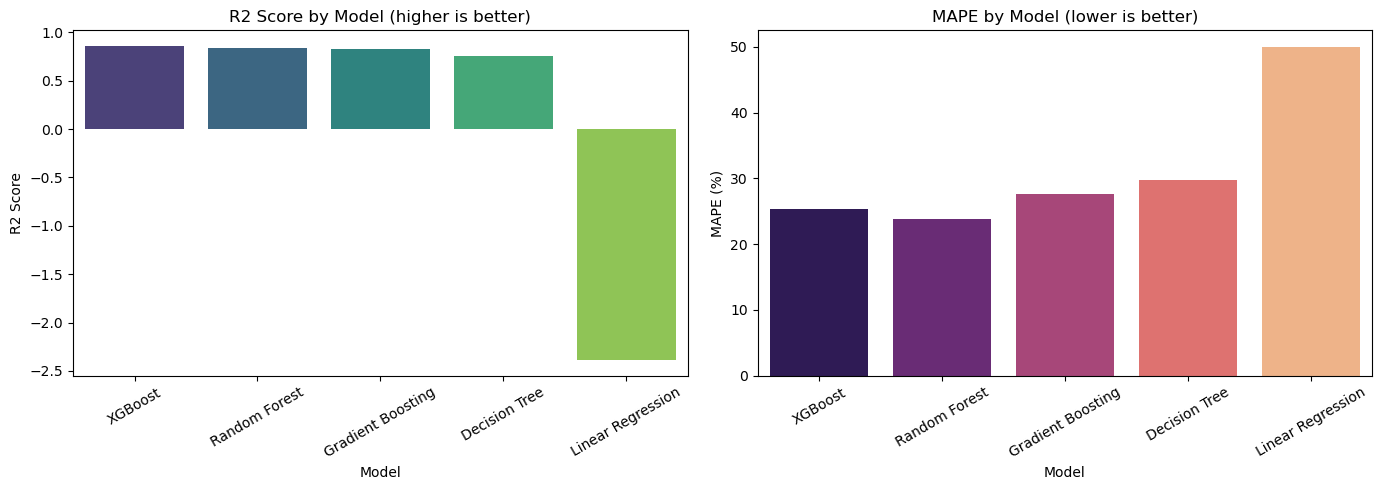

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df, x="Model", y="R2 Score", ax=axes[0], palette="viridis")
axes[0].set_title("R2 Score by Model (higher is better)")
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=results_df, x="Model", y="MAPE (%)", ax=axes[1], palette="magma")
axes[1].set_title("MAPE by Model (lower is better)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("../reports/figures/model_comparison.png", dpi=120)
plt.show()


## 4. Select and Save the Best Model

In [5]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Best model: {best_model_name}")

joblib.dump(best_model, "../models/best_model.pkl")
results_df.to_csv("../models/model_comparison.csv", index=False)
print("Saved best_model.pkl and model_comparison.csv")


Best model: XGBoost
Saved best_model.pkl and model_comparison.csv


## 5. Feature Importance (tree-based models)

C:\Users\DELL\AppData\Local\Temp\ipykernel_15992\935769215.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="crest")


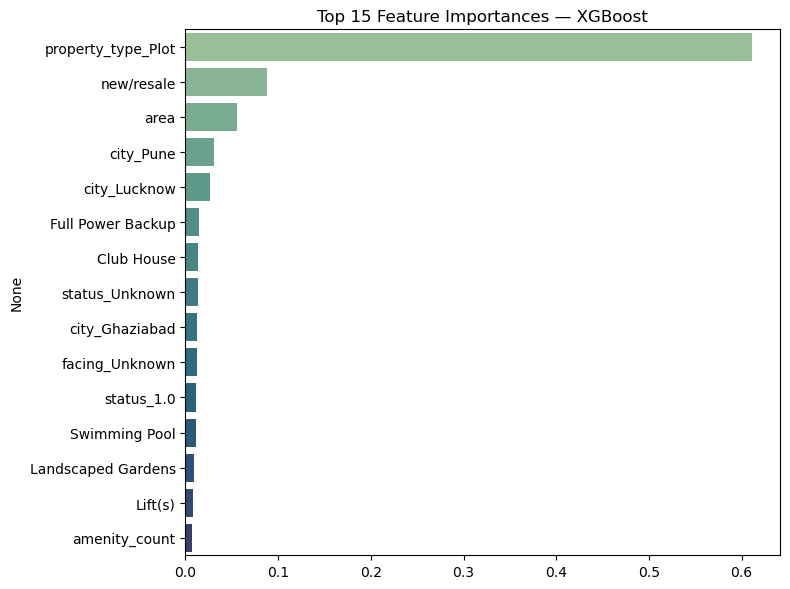

In [6]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, palette="crest")
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.savefig("../reports/figures/feature_importance.png", dpi=120)
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_ directly.")


---
**Next notebook:** `05_evaluation.ipynb` — deeper error analysis, residual plots, and a written model performance summary for the report.
